In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### handle missing values

In [7]:
df["Income"]  = df["Income"].fillna(df["Income"].median) 

## Feature Engineering

In [8]:
##create new feature
df['Age'] = 2026- df["Year_Birth"]

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [10]:
ref_date = df["Dt_Customer"].max()

In [11]:
df["Customer_tenure_days"] = (ref_date - df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
#spending

df['Total_Spending'] = df["MntWines"] + df["MntFruits"] +  df["MntMeatProducts"] + df["MntFishProducts"] +  df["MntSweetProducts"] +  df["MntGoldProds"] 

In [14]:
df["Total_Children"] =  df["Kidhome"] + df["Teenhome"]

In [15]:
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Basic" : "undergraduate",
    "2n Cycle" : "undergraduate",
    "Graduation" : "graduate",
    "Master" : "postgraduate",
    "PhD" :  "postgraduate"
})

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children
0,5524,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
df["Living_with"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Absurd" : "Alone",
    "YONO" : "Alone"
})

In [22]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_with
0,5524,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [23]:
cols = ["ID", "Year_Birth", "Marital_Status","Teenhome","Kidhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='object')

In [24]:
df_cleaned.shape

(2240, 15)

In [25]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

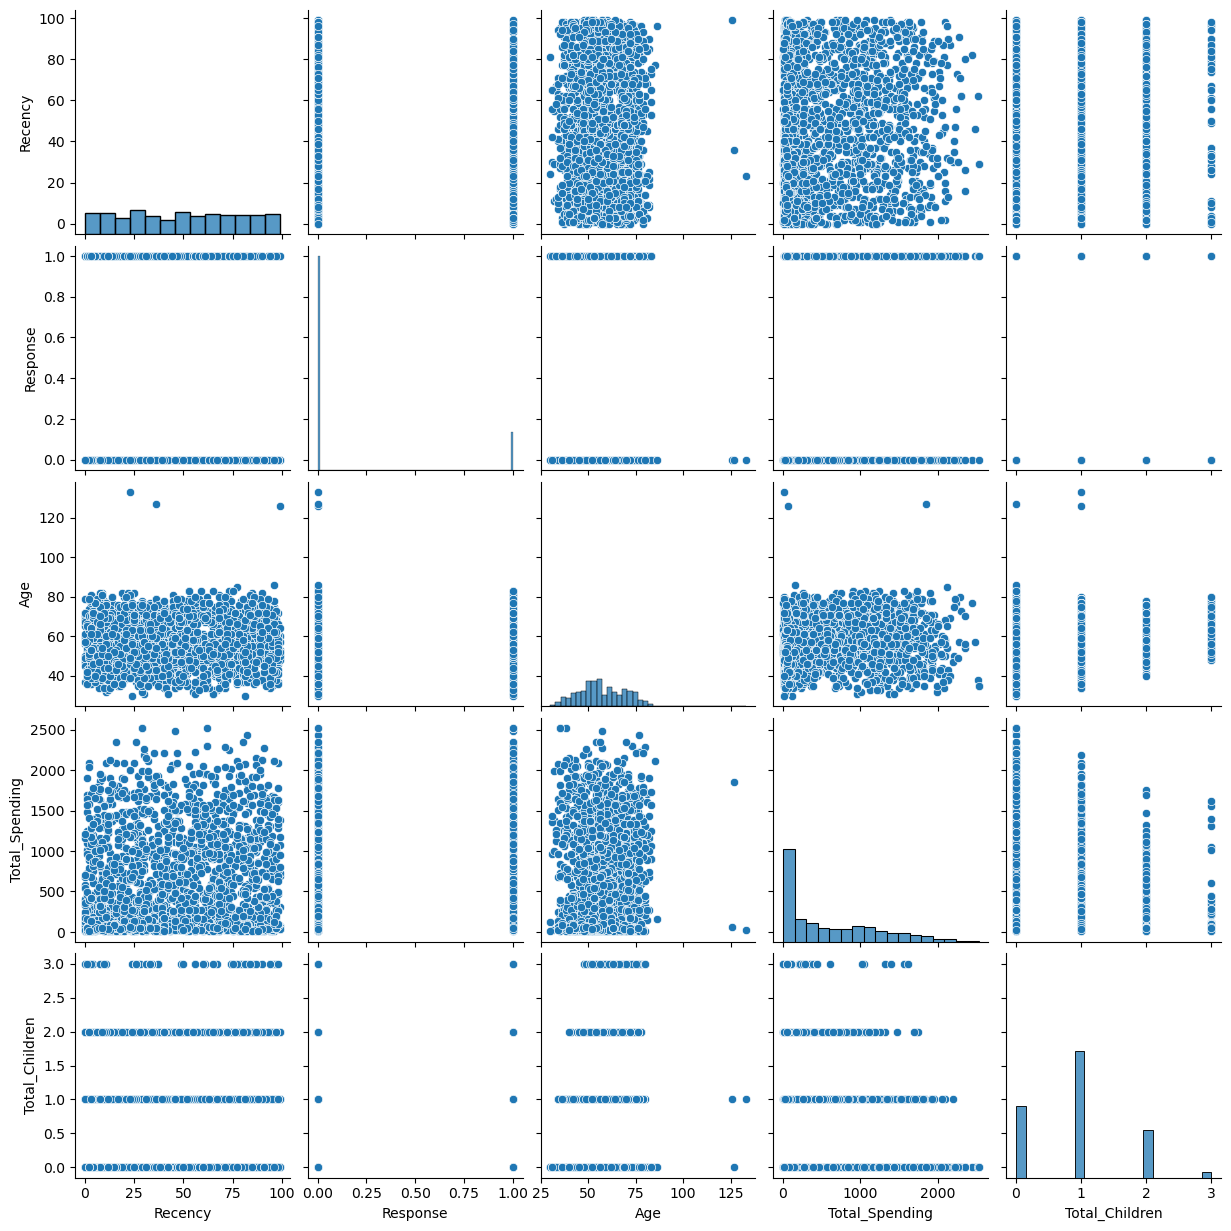

In [27]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending","Total_Children"]

#re;ative Plot

sns.pairplot(df_cleaned[cols])

In [29]:
#Remove outliers

print("data.size.with outliers", len(df_cleaned))

data.size.with outliers 2240


In [50]:
df_cleaned["Income"] = pd.to_numeric(df_cleaned["Income"], errors="coerce")

In [51]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                  0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
Age                     0
Customer_tenure_days    0
Total_Spending          0
Total_Children          0
Living_with             0
dtype: int64

In [52]:
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90 )]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000 )]

# HeatMap

In [54]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

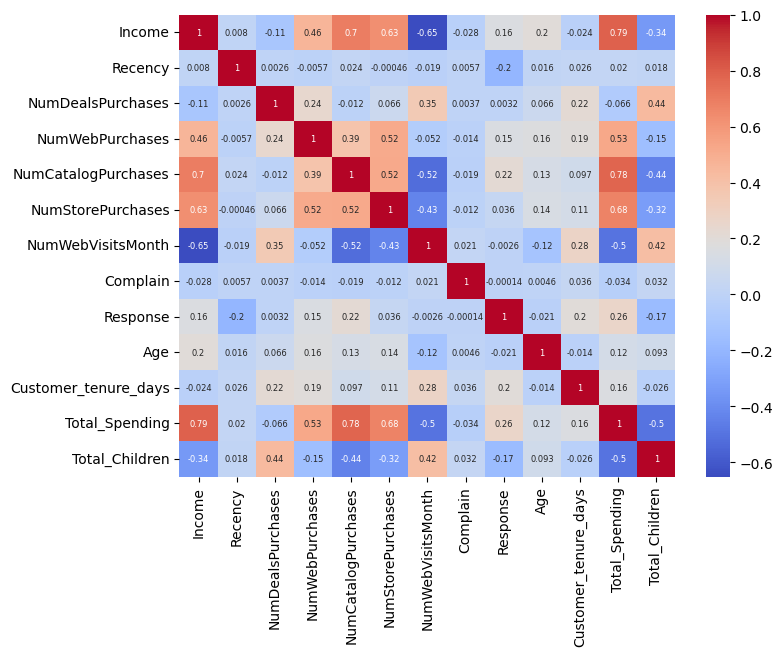

In [57]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size" : 6},
    cmap="coolwarm"
)

In [62]:
from sklearn.preprocessing import OneHotEncoder

In [65]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [66]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [69]:
enc_df.head()

,Education_graduate,Education_postgraduate,Education_undergraduate,Living_with_Alone,Living_with_Partner,Living_with_YOLO
0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


In [71]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [73]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_graduate,Education_postgraduate,Education_undergraduate,Living_with_Alone,Living_with_Partner,Living_with_YOLO
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0.0


## scalling

In [74]:
from sklearn.preprocessing import StandardScaler

In [75]:
X = df_encoded

In [77]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [78]:
X_scaled.shape

(2212, 19)

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [90]:
pca.explained_variance_ratio_

array([0.22034503, 0.10780881, 0.09907602])

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'PCA3')

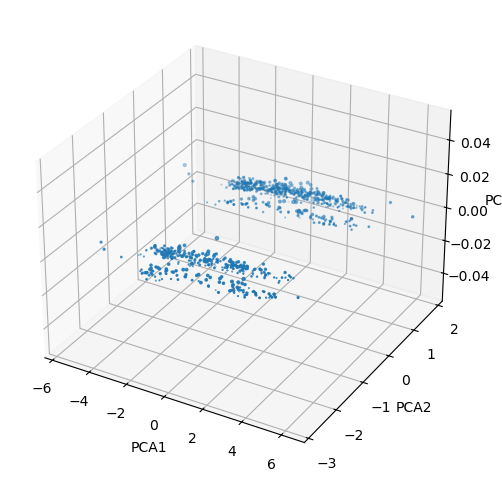

In [96]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
     X_pca[:,2]
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

## Analyze K value

### 1. Elbow Method

In [99]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11) : 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [101]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [102]:
print("Best K:", optimal_k)

Best K: 4


Text(0, 0.5, 'wcss')

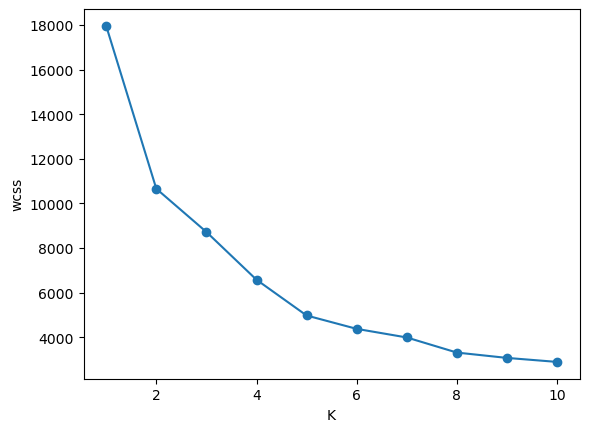

In [105]:
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("K")
plt.ylabel("wcss")

Text(0, 0.5, 'Silhouette score')

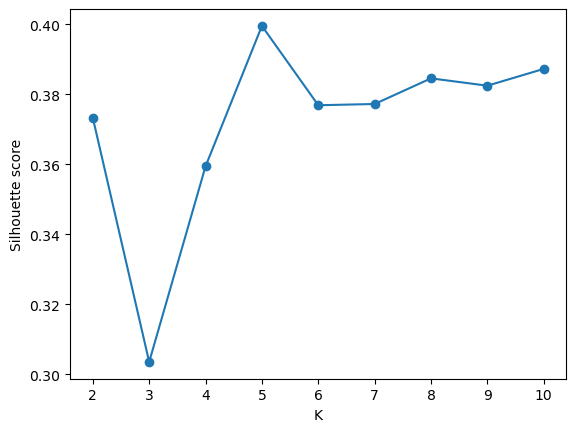

In [108]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)


#plot
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

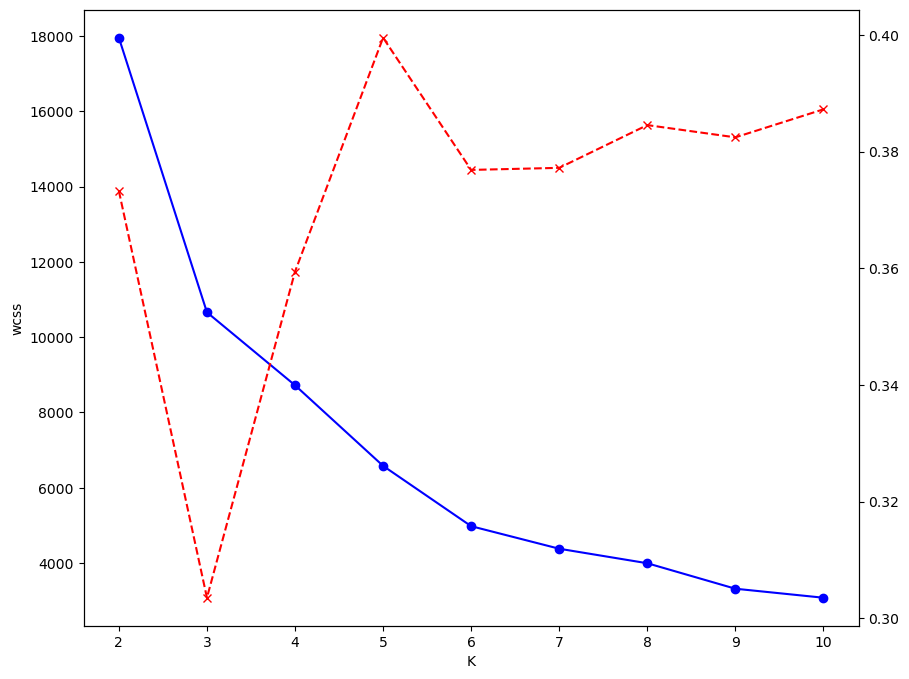

In [113]:
#combined

k_range = range(2, 11)
fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2 .plot(k_range, scores[:len(k_range)], marker='x', color='red', linestyle='--')

In [114]:
#K_Means

k_means = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'PCA3')

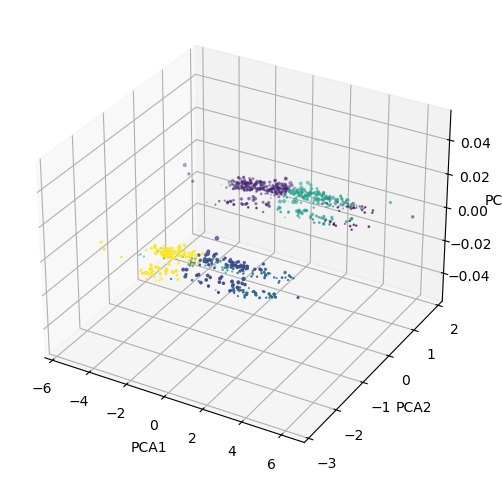

In [116]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
     X_pca[:,2],
    c=labels_kmeans
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

In [117]:
#Agglomerative
from sklearn.cluster import AgglomerativeClustering

In [118]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'PCA3')

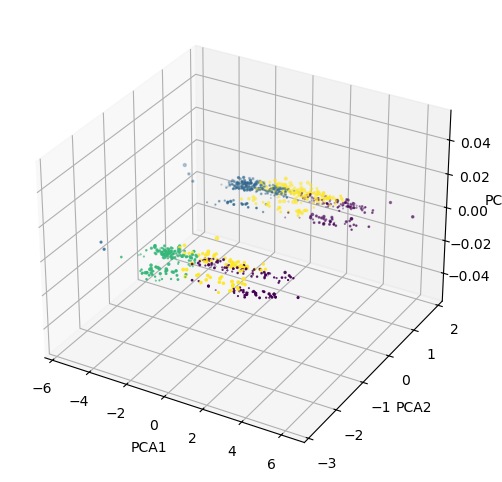

In [120]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
     X_pca[:,2],
    c=labels_agg
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

# Chracterization of Clusters

In [124]:

df_cleaned = df_cleaned.drop("labels", axis=1)
df_cleaned["clusters"] = labels_agg

In [125]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_with,clusters
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,0
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,0
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,1
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,1


In [129]:
pal = ["red", "blue", "yellow","green"]

<Axes: xlabel='clusters', ylabel='count'>

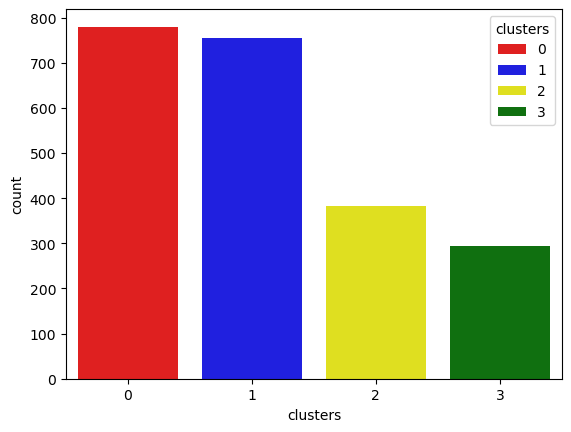

In [131]:
sns.countplot(x=df_cleaned["clusters"], palette=pal, hue=df_cleaned["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

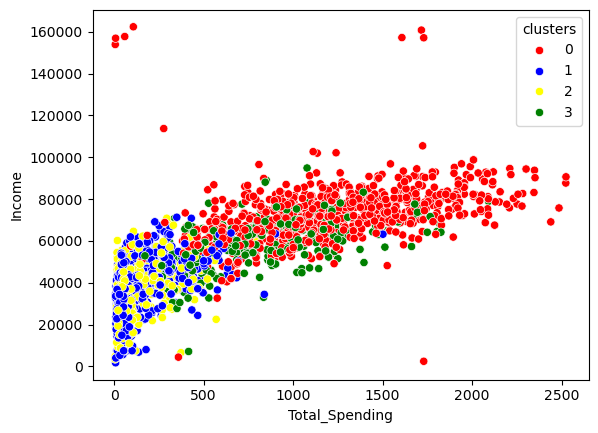

In [132]:
sns.scatterplot(
    x=df_cleaned["Total_Spending"],
    y=df_cleaned["Income"],
    hue = df_cleaned["clusters"],
    palette=pal

)

In [141]:
X["clusters"] = labels_agg

In [143]:
#Cluster summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         72761.515385  49.261538           1.743590         5.492308   
1         36366.985450  49.661376           2.272487         2.548942   
2         35288.879896  48.000000           2.268930         2.415144   
3         58600.085324  48.051195           4.078498         6.508532   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    5.315385           8.405128           3.369231  0.008974   
1                    0.691799           3.588624           6.465608  0.010582   
2                    0.660574           3.344648           6.511749  0.013055   
3                    3.375427           7.829352           6.010239  0.000000   

          Response        Age  Customer_tenure_days  Total_Spending  \
clu